# ⚽ Football Analytics with Python
## Chapter 3 — Themes and Colour Palettes

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-03-Themes-and-Colour-Palettes/Chapter_03_Themes_and_Colour_Palettes.ipynb)

---

### What This Chapter Is About

In Chapters 1 and 2, we told you to use colours like `BG = '#0d1117'`
and `WHITE = '#f0f6fc'`. We gave you the code. We did not explain why.

Chapter 3 is where we explain why.

Design is not decoration. In data visualisation, every design decision —
the background colour, the width of a grid line, whether to show the chart
border or not — affects how quickly a reader extracts information from the chart.

**A well-designed chart communicates faster than a poorly-designed one with
identical data.** That is not an opinion. It is perceptual psychology. And
in a world where your reader has 8 seconds before they scroll past, faster
communication is the difference between insight and noise.

This chapter teaches you:
- Why every design decision in this course was made
- How to build a reusable colour palette that works for any analysis
- How to write a `style_axis()` function — one line that makes any chart professional
- The performance tier system — how to colour by meaning, not just by player
- How to switch between dark and light themes using the same chart code

### What You Will Build

Three things. In increasing order of sophistication:

1. **A palette swatch chart** — see every colour in the system at once
2. **A before / after comparison** — the same chart, default vs designed
3. **A tiered performance chart** — bars coloured by whether a player is elite, average, or below average

### The Dataset

`data/chapter03_players.csv` — the Chapter 2 clean data, extended with
two new columns: `gi_percentile` (estimated percentile rank for GI/90)
and `tier` (Elite / Above Average / Average / Below Average).

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

---
## Part 1 — Why Design Is Not Optional

### The 8-Second Rule

Research on digital content consumption shows the average reader spends
8 seconds on a chart before deciding whether to engage with it or scroll past.

In those 8 seconds, the brain is not reading the data. It is asking three questions:

1. **Is this readable?** (contrast, font size, background)
2. **Do I know where to look?** (visual hierarchy, emphasis)
3. **Does this feel credible?** (consistency, professionalism)

If any of those questions gets a "no", the reader moves on — regardless of
how good the underlying analysis is.

**Design is not about making things pretty. It is about making things fast to read.**

---

### The Five Design Decisions That Matter Most

Everything else is secondary. These five decisions are what separate a chart
that communicates from one that merely displays.

| Decision | Bad Default | Good Choice | Why |
|----------|------------|-------------|-----|
| **Background** | White | Dark (`#0d1117`) | Dark backgrounds increase perceived contrast — colours appear more vivid and text is sharper |
| **Grid lines** | Solid, dark | Subtle, 7% opacity | Grid lines should help the eye measure, not compete with the data |
| **Chart border** | Full box (all 4 sides) | Bottom and left only | The top and right borders add visual noise without adding information |
| **Typography** | Default font, default size | Explicit sizes, white text, bold titles | Type hierarchy guides the reader: title → subtitle → axis labels → tick labels |
| **Colour** | Default matplotlib rainbow | Intentional, consistent palette | Random colours make the reader decode colour before reading data; intentional colour carries meaning |

We implement all five of these in the `style_axis()` function you will build
in Part 4. Once written, you never have to think about them individually again.

---

### Pre-attentive Attributes — The Science Behind Colour Choice

Your brain processes certain visual properties before conscious attention.
These are called **pre-attentive attributes**. They include:

- **Colour** — the fastest. You see red before you see "red"
- **Size** — bigger = more important, instantly
- **Position** — things in the top-right feel prominent
- **Orientation** — a diagonal line in a field of horizontal ones pops immediately

When we give Lamine Yamal the colour `#A50044` (Barça deep red) and
keep it consistent across all 8 charts in an analysis, the reader's brain
builds a pre-attentive association: deep red = Yamal.

By Chart 3, they do not read the label. They recognise the colour.
That is 0.3 seconds per chart saved. Across 8 charts and 10,000 readers,
that is meaningful.

---

### Colour Blindness — Designing for Everyone

Approximately 8% of men and 0.5% of women have some form of colour vision
deficiency. The most common is red-green colour blindness — difficulty
distinguishing red from green.

**This is why we never use red and green as the only way to distinguish
two players or two teams.** We pair colour with shape (different marker styles),
size (bigger dot = focus player), and position (legend with labels).

For performance tiers, we use red/yellow/green — but we always add text labels
so the colour is not the only signal. A reader who cannot distinguish red from
green still reads "Below Average" from the label.

---
## Part 2 — Setup

Same pattern as Chapters 1 and 2. Run both cells first.

In [1]:
# CELL 1 — Install and import
!pip install pandas matplotlib numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
%matplotlib inline
plt.rcParams['figure.dpi'] = 150

print("✓ Ready.")

✓ Ready.


In [1]:
# CELL 2 — The complete BarcaFutbol design system
# This is the canonical version — the one we will import in every chapter from here

# ── Backgrounds ────────────────────────────────────────────────────────────
BG  = '#0d1117'   # Base background — near-black
BG2 = '#0d1b2a'   # Slightly lighter — radar backgrounds
BG3 = '#161b22'   # Darkest surface — legend panels

# ── Text ───────────────────────────────────────────────────────────────────
WHITE = '#f0f6fc'  # All labels, titles, axis text
GRAY  = '#8b949e'  # Secondary text, grid lines, axis spines

# ── Accent ─────────────────────────────────────────────────────────────────
GOLD = '#EDBB00'   # Reference lines, highlights, annotations

# ── Performance tiers ──────────────────────────────────────────────────────
# These colours communicate performance level — not just player identity
GREEN  = '#4CAF50'  # Elite      — 70th percentile or above
YELLOW = '#ffd60a'  # Average    — 40th to 69th percentile
ORANGE = '#FF9800'  # Developing — 20th to 39th percentile
RED    = '#e63946'  # Below avg  — below 20th percentile

# Map tier names to colours — used in tiered charts
TIER_COLORS = {
    'Elite':         GREEN,
    'Above Average': YELLOW,
    'Average':       ORANGE,
    'Below Average': RED,
}

# ── Player colours — one unique colour per player ─────────────────────────
PLAYER_COLORS = {
    'Marcus Silva':   '#3498DB',   # blue
    'Lucas Ferreira': '#2ecc71',   # green
    'James Thornton': '#e74c3c',   # red
    'Diego Varela':   '#9B59B6',   # purple
    'Amir Hassan':    '#FF9800',   # orange
    'Kai Becker':     '#00BCD4',   # cyan
    'Tom Wheeler':    '#F06292',   # pink
    'Sam Okafor':     '#80CBC4',   # teal
    'Elena Rossi':    '#FFD54F',   # yellow
    'Carlos Mendez':  '#CE93D8',   # lavender
    'Jin Park':       '#A5D6A7',   # mint
}

print("✓ Design system loaded.")
print(f"  Defined: BG, BG2, BG3, WHITE, GRAY, GOLD")
print(f"  Defined: GREEN, YELLOW, ORANGE, RED")
print(f"  Defined: TIER_COLORS (4 tiers)")
print(f"  Defined: PLAYER_COLORS (11 players)")

✓ Design system loaded.
  Defined: BG, BG2, BG3, WHITE, GRAY, GOLD
  Defined: GREEN, YELLOW, ORANGE, RED
  Defined: TIER_COLORS (4 tiers)
  Defined: PLAYER_COLORS (11 players)


---
## Part 3 — Visualising the Palette

Before using colours in a chart, visualise the palette itself.
This tells you immediately if any two colours are too similar,
if anything clashes with the background, or if the contrast
between text and background is insufficient.

The swatch chart below shows every colour in the system.
Each swatch shows the hex code and its purpose.

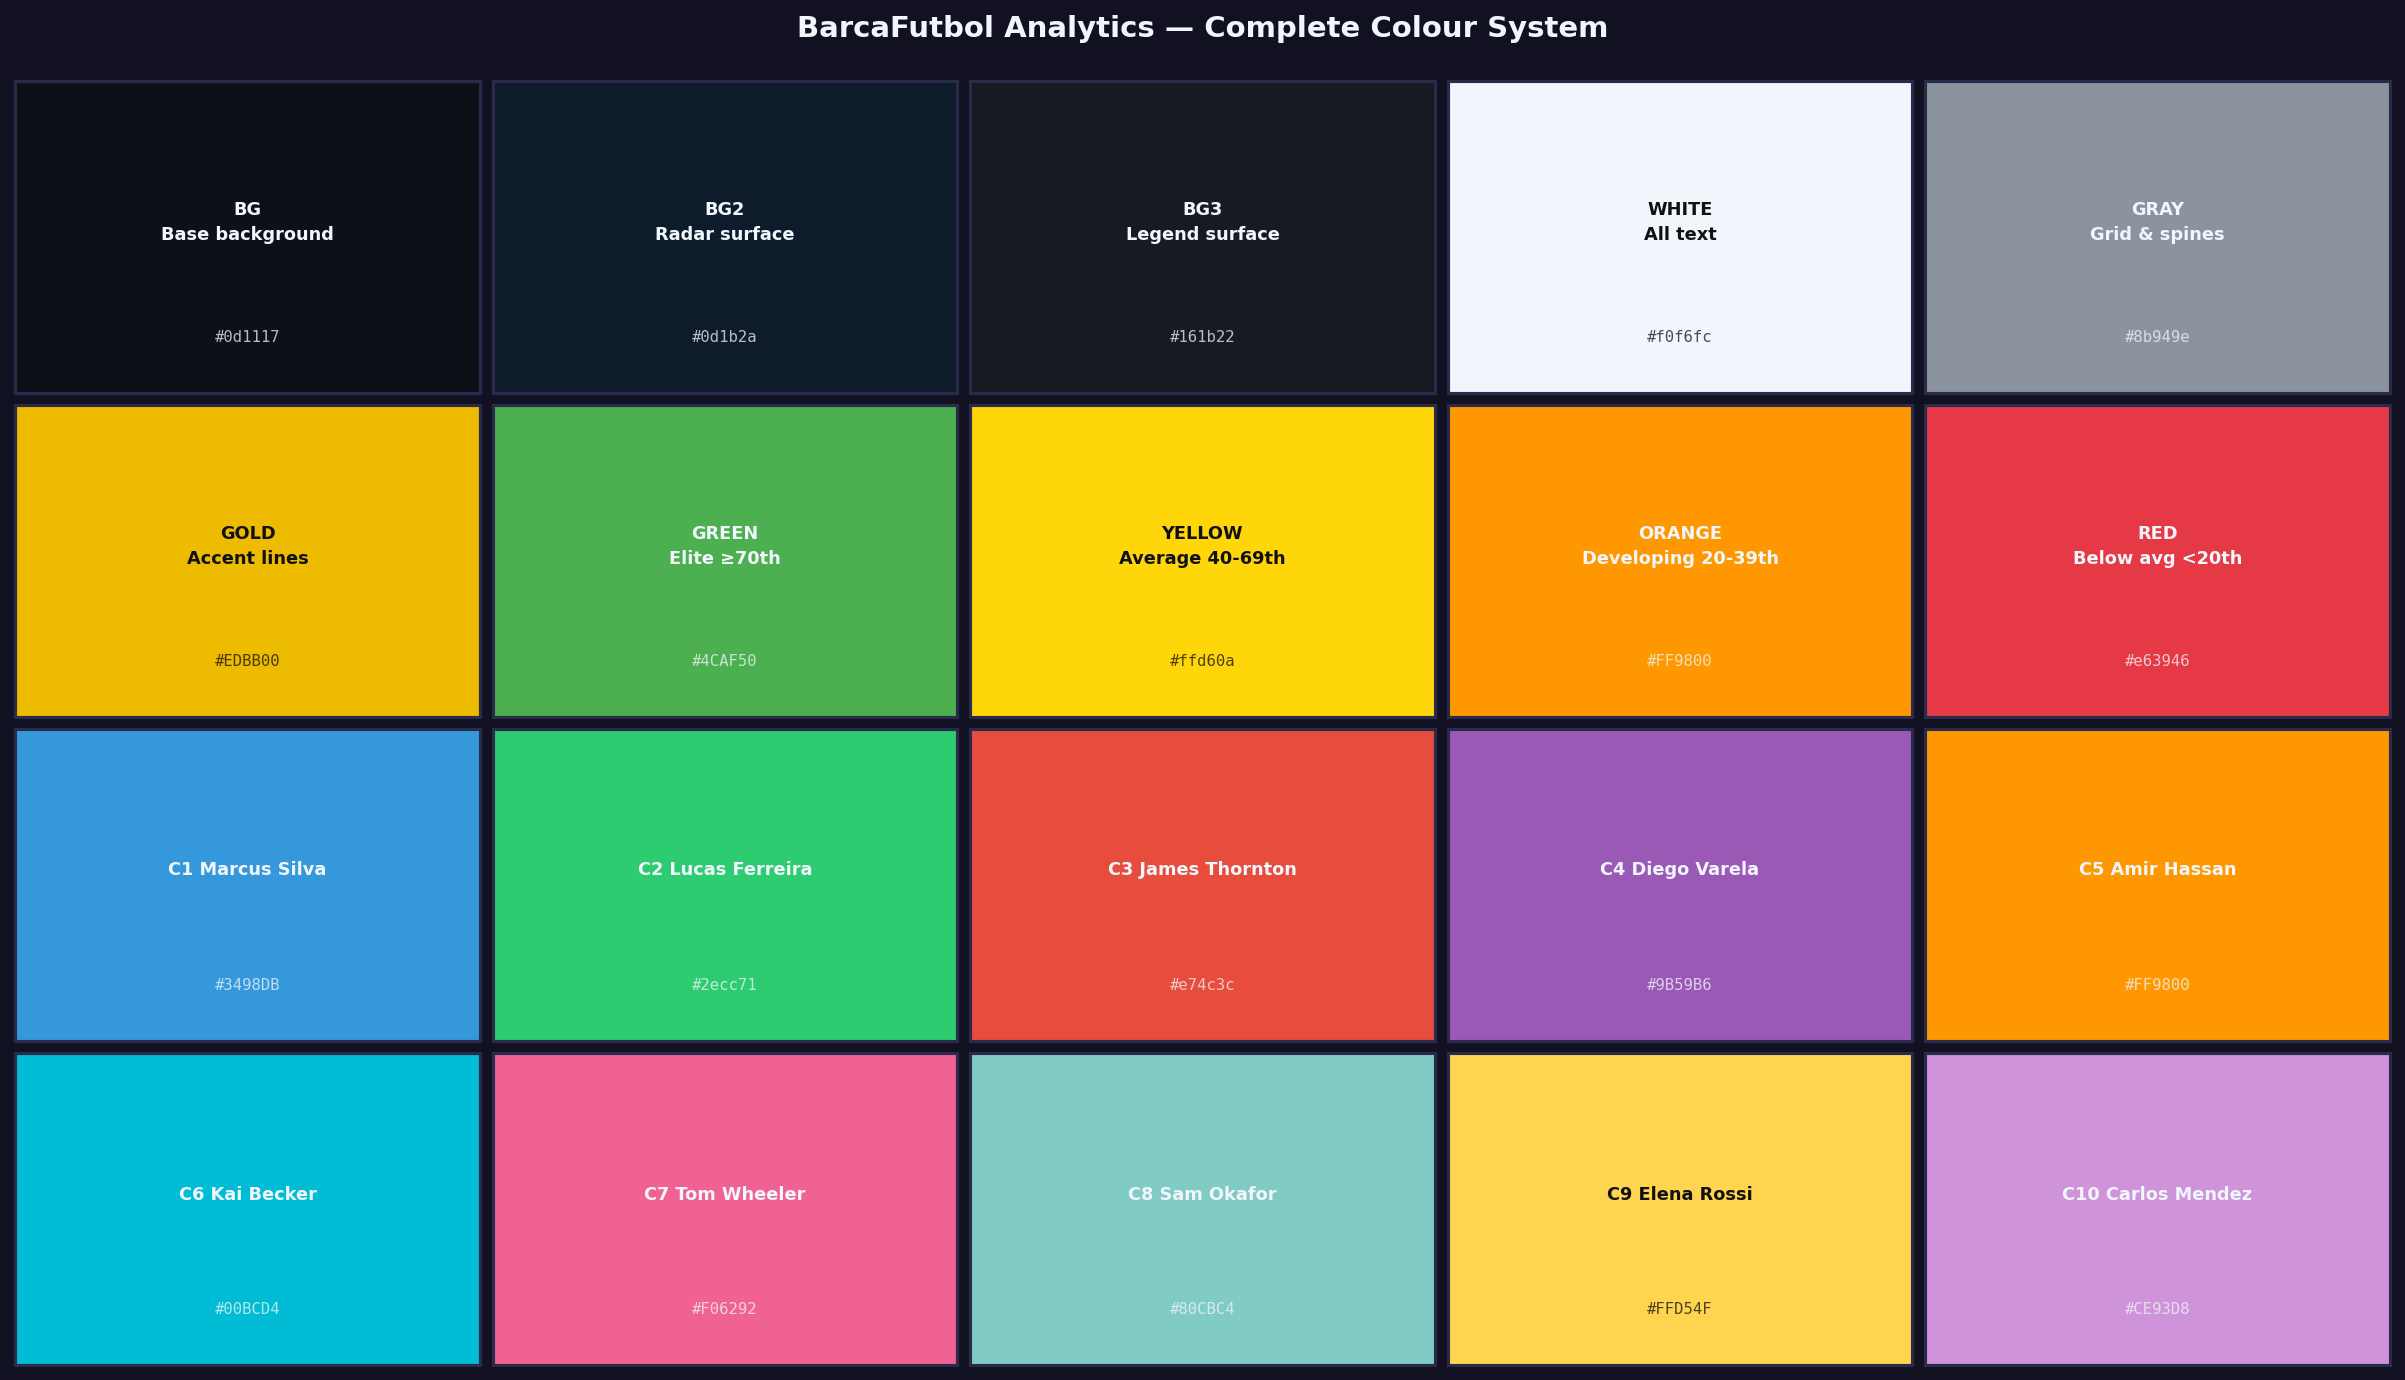

In [1]:
# CELL 3 — Palette swatch chart
# Visualise every colour in the design system before using it

palette_items = [
    # (hex_colour,  hex_string,  label)
    (BG,      '#0d1117',  'BG\nBase background'),
    (BG2,     '#0d1b2a',  'BG2\nRadar surface'),
    (BG3,     '#161b22',  'BG3\nLegend surface'),
    (WHITE,   '#f0f6fc',  'WHITE\nAll text'),
    (GRAY,    '#8b949e',  'GRAY\nGrid & spines'),
    (GOLD,    '#EDBB00',  'GOLD\nAccent lines'),
    (GREEN,   '#4CAF50',  'GREEN\nElite ≥70th'),
    (YELLOW,  '#ffd60a',  'YELLOW\nAverage 40–69th'),
    (ORANGE,  '#FF9800',  'ORANGE\nDeveloping 20–39th'),
    (RED,     '#e63946',  'RED\nBelow avg <20th'),
    ('#3498DB','#3498DB', 'C1 Marcus Silva'),
    ('#2ecc71','#2ecc71', 'C2 Lucas Ferreira'),
    ('#e74c3c','#e74c3c', 'C3 James Thornton'),
    ('#9B59B6','#9B59B6', 'C4 Diego Varela'),
    ('#FF9800','#FF9800', 'C5 Amir Hassan'),
    ('#00BCD4','#00BCD4', 'C6 Kai Becker'),
    ('#F06292','#F06292', 'C7 Tom Wheeler'),
    ('#80CBC4','#80CBC4', 'C8 Sam Okafor'),
    ('#FFD54F','#FFD54F', 'C9 Elena Rossi'),
    ('#CE93D8','#CE93D8', 'C10 Carlos Mendez'),
]

fig, axes = plt.subplots(4, 5, figsize=(16, 9))
fig.patch.set_facecolor('#111122')
axes_flat = axes.flatten()

for ax, (color, hex_code, label) in zip(axes_flat, palette_items):
    ax.set_facecolor(color)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a4a')
        spine.set_linewidth(1.5)

    # Use dark text on light swatches, white on dark swatches
    light_colors = {WHITE, YELLOW, '#ffd60a', '#FFD54F', '#EDBB00', GOLD}
    text_color = '#111111' if color in light_colors else WHITE

    ax.text(0.5, 0.55, label,
            ha='center', va='center', fontsize=8.5,
            color=text_color, fontweight='bold',
            multialignment='center', transform=ax.transAxes,
            linespacing=1.5)
    ax.text(0.5, 0.18, hex_code,
            ha='center', va='center', fontsize=7.5,
            color=text_color, alpha=0.75,
            transform=ax.transAxes, family='monospace')

fig.suptitle('BarcaFutbol Analytics — Complete Colour System',
             color=WHITE, fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.6)
plt.show()

### What to Notice

- **The backgrounds (BG, BG2, BG3)** are three shades of near-black. They look
  similar here but create a subtle depth hierarchy in complex charts — darker
  backgrounds feel "further back", lighter ones feel "closer".

- **GOLD, GREEN, YELLOW, ORANGE, RED** — these are the five functional colours.
  They carry meaning: gold = reference, green = elite, yellow = average,
  orange = developing, red = below average. Use them consistently.

- **The player colours** span the full spectrum deliberately — no two are visually
  adjacent. Look at C1 (blue) vs C2 (green) vs C3 (red) vs C4 (purple). Each is
  immediately distinguishable, even at small sizes.

- **On light swatches (WHITE, YELLOW, GOLD)**, we use dark text. On dark swatches,
  white text. The code detects which to use automatically with `light_colors`.
  This is the accessibility check built into the palette.

---
## Part 4 — The `style_axis()` Function

### The Problem This Solves

Every chart we build in this course requires the same 8–10 lines of styling code:
dark background, white tick labels, GRAY spines, remove top/right borders,
subtle grid, white axis labels.

If we write those 10 lines in every chart cell, we will write them 40+ times
across the course. More importantly, if we ever want to change something —
say, make grid lines slightly more visible — we have to change it in 40 places.

**The solution: write it once as a function. Call it once per chart.**

This is called the **DRY principle** — Don't Repeat Yourself. It is one of
the most important habits in programming.

### What `style_axis()` Does

The function takes an `ax` object (the chart area) and applies the full
BarcaFutbol design system to it in one call:

```python
style_axis(ax)  # that's it — one line
```

Everything else is handled automatically.

In [1]:
# CELL 4 — The style_axis() function
# Write this once. Use it in every chart from Chapter 3 onward.

def style_axis(ax, theme='dark', xlabel=None, ylabel=None,
               title=None, subtitle=None):
    """
    Apply the BarcaFutbol design system to any matplotlib axes object.

    Parameters
    ----------
    ax       : matplotlib Axes  — the chart to style
    theme    : 'dark' or 'light' — default is dark
    xlabel   : str  — x-axis label text (optional)
    ylabel   : str  — y-axis label text (optional)
    title    : str  — chart title (optional)
    subtitle : str  — subtitle shown below title (optional)

    Usage
    -----
    fig, ax = plt.subplots(figsize=(12, 7))
    # ... draw your chart ...
    style_axis(ax, xlabel='Goals per 90', ylabel='Player', title='My Chart')
    plt.show()
    """
    if theme == 'dark':
        bg       = BG
        text_col = WHITE
        grid_col = WHITE
        spine_col= GRAY
    else:  # light theme
        bg       = '#f8f9fa'
        text_col = '#1a1a2e'
        grid_col = '#cccccc'
        spine_col= '#888888'

    # ── Background ────────────────────────────────────────────────
    ax.set_facecolor(bg)

    # ── Spines (chart borders) ────────────────────────────────────
    # Keep only bottom and left — remove top and right
    ax.spines['bottom'].set_color(spine_col)
    ax.spines['left'].set_color(spine_col)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Tick labels ───────────────────────────────────────────────
    ax.tick_params(colors=text_col, labelsize=10)

    # ── Grid lines ────────────────────────────────────────────────
    # Subtle — guides the eye without competing with the data
    ax.grid(True, alpha=0.07, color=grid_col, linewidth=0.8)

    # ── Axis labels ───────────────────────────────────────────────
    if xlabel:
        ax.set_xlabel(xlabel, color=text_col, fontsize=11, labelpad=8)
    if ylabel:
        ax.set_ylabel(ylabel, color=text_col, fontsize=11, labelpad=8)

    # ── Title ─────────────────────────────────────────────────────
    if title and subtitle:
        ax.set_title(f'{title}\n{subtitle}',
                     color=text_col, fontsize=13,
                     fontweight='bold', pad=15, linespacing=1.6)
    elif title:
        ax.set_title(title, color=text_col, fontsize=13,
                     fontweight='bold', pad=12)

    return ax   # return ax so the function can be chained

print("✓ style_axis() function defined.")
print()
print("Usage:")
print("  fig, ax = plt.subplots(figsize=(12, 7))")
print("  ax.barh(players, values, color=colors)")
print("  style_axis(ax, xlabel='GI per 90', title='My Chart')")
print("  plt.show()")

✓ style_axis() function defined.

Usage:
  fig, ax = plt.subplots(figsize=(12, 7))
  ax.barh(players, values, color=colors)
  style_axis(ax, xlabel='GI per 90', title='My Chart')
  plt.show()


---
## Part 5 — Before and After: The Same Chart, Two Ways

### Loading the Data

In [1]:
# CELL 5 — Load the Chapter 3 dataset
df = pd.read_csv('data/chapter03_players.csv')
df_sorted = df.sort_values('gi_per90', ascending=True)

print(f"Loaded: {len(df)} players")
print()
print(df[['player','gi_per90','gi_percentile','tier']].to_string(index=False))

Loaded: 11 players

        player  gi_per90  gi_percentile          tier
  Marcus Silva      0.86             91         Elite
 Carlos Mendez      0.72             82         Elite
James Thornton      0.79             86         Elite
Lucas Ferreira      0.75             84         Elite
   Amir Hassan      0.77             85         Elite
   Tom Wheeler      0.77             83         Elite
  Diego Varela      0.70             74 Above Average
    Kai Becker      0.65             68 Above Average
    Sam Okafor      0.44             42       Average
   Elena Rossi      0.52             51       Average
      Jin Park      0.45             38 Below Average


### The Before — matplotlib Defaults

This is what matplotlib produces with zero styling.
It works. It is readable. But it communicates nothing about the quality
of the analysis behind it.

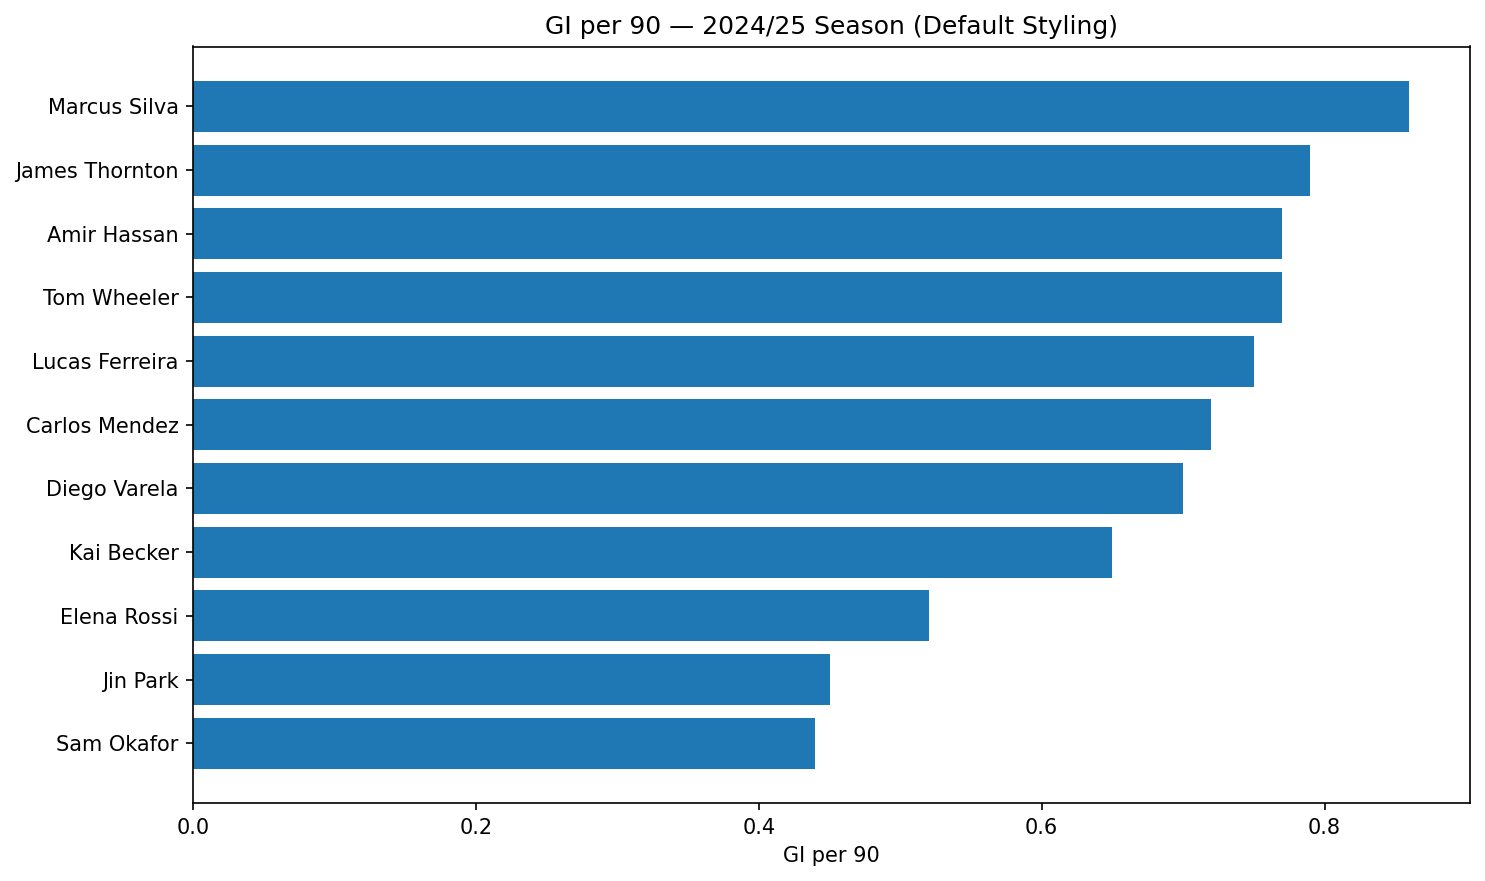

This is what matplotlib gives you with zero design decisions.
Now compare it to the next cell.


In [1]:
# CELL 6 — The BEFORE chart: default matplotlib styling
df_sorted = df.sort_values('gi_per90', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(df_sorted['player'], df_sorted['gi_per90'])
ax.set_xlabel('GI per 90')
ax.set_title('GI per 90 — 2024/25 Season (Default Styling)')

plt.tight_layout()
plt.show()

print("This is what matplotlib gives you with zero design decisions.")
print("Now compare it to the next cell.")

### The After — BarcaFutbol Design System

**Same data. Same numbers. Completely different impression.**

Notice specifically what changed — and more importantly, *why* each change
was made. Every decision has a reason.

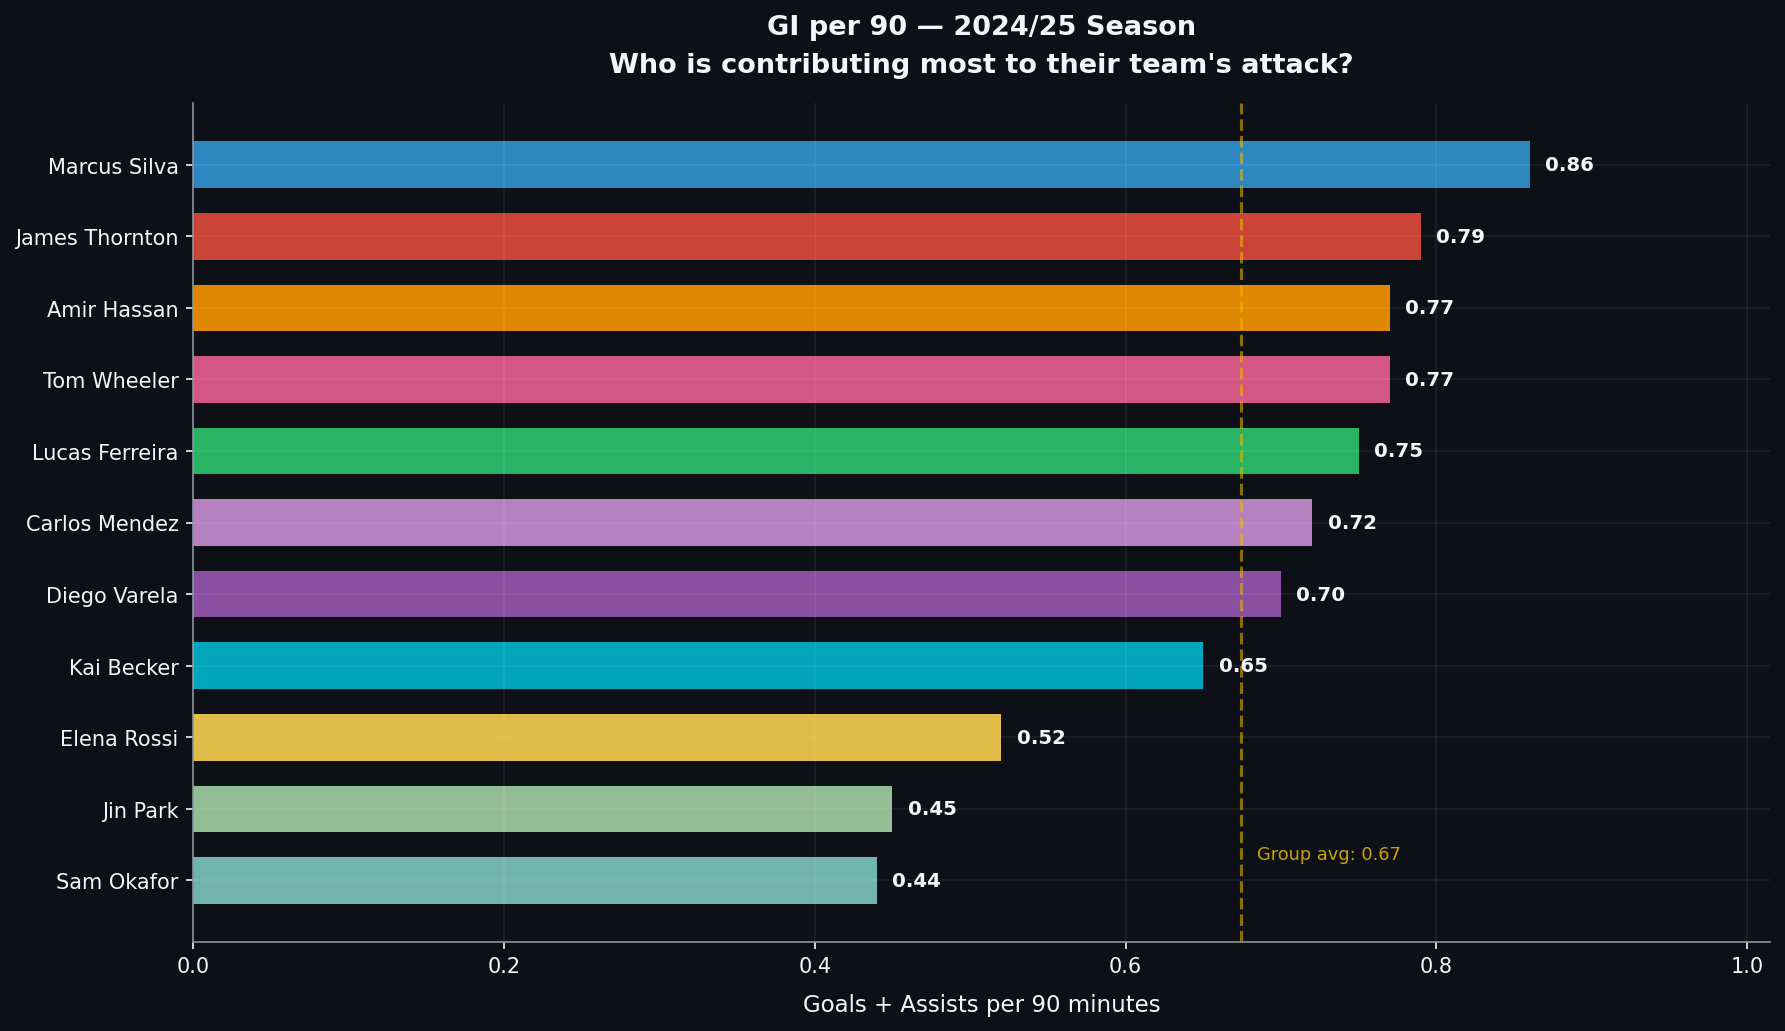

In [1]:
# CELL 7 — The AFTER chart: full BarcaFutbol design system
df_sorted = df.sort_values('gi_per90', ascending=True)
bar_colors = [PLAYER_COLORS.get(p, GRAY) for p in df_sorted['player']]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)          # 1. Dark background on the whole figure

bars = ax.barh(df_sorted['player'], df_sorted['gi_per90'],
               color=bar_colors,      # 2. Unique colour per player
               alpha=0.88, height=0.65)

# 3. Value labels — reader sees the number without squinting at the axis
for bar, val in zip(bars, df_sorted['gi_per90']):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            color=WHITE, fontsize=9.5, fontweight='bold')

# 4. Gold average line — context without clutter
avg = df_sorted['gi_per90'].mean()
ax.axvline(x=avg, color=GOLD, linestyle='--', alpha=0.55, linewidth=1.5)
ax.text(avg + 0.01, 0.3, f'Group avg: {avg:.2f}',
        color=GOLD, fontsize=8.5, alpha=0.85)

# 5. Apply the design system — ONE LINE replaces 8 lines of repetitive styling
style_axis(ax,
           xlabel='Goals + Assists per 90 minutes',
           title='GI per 90 — 2024/25 Season',
           subtitle="Who is contributing most to their team's attack?")

ax.set_xlim(0, df_sorted['gi_per90'].max() * 1.18)

plt.tight_layout()
plt.show()

### What Changed — and Why

| Change | Before | After | Reason |
|--------|--------|-------|--------|
| Background | White | `#0d1117` near-black | Dark = higher contrast, more vivid colours |
| Bar colours | Default blue | Unique per player | Pre-attentive — the eye reads colour before reading text |
| Value labels | None | `0.86` at bar end | Reader sees the number immediately, no squinting at the axis |
| Average line | None | Gold dashed line | Context — above/below average is visible at a glance |
| Chart border | All 4 sides | Left + bottom only | Top and right borders are noise, not information |
| Grid lines | Solid dark | 7% white opacity | Grid guides without competing with data |
| Typography | Default | Explicit sizes, white | Type hierarchy: title → subtitle → labels → ticks |
| Title | Single line | Title + subtitle | First line = what, second line = why |

**Note:** The "After" chart uses `style_axis()` once to apply everything except
the value labels and average line. That is the function's job.

---

## Part 6 — The Performance Tier System

### Colouring by Meaning, Not by Player

Sometimes the most important question is not *who* is performing well
but *how many* players are in each performance tier. For that question,
we colour by tier, not by player.

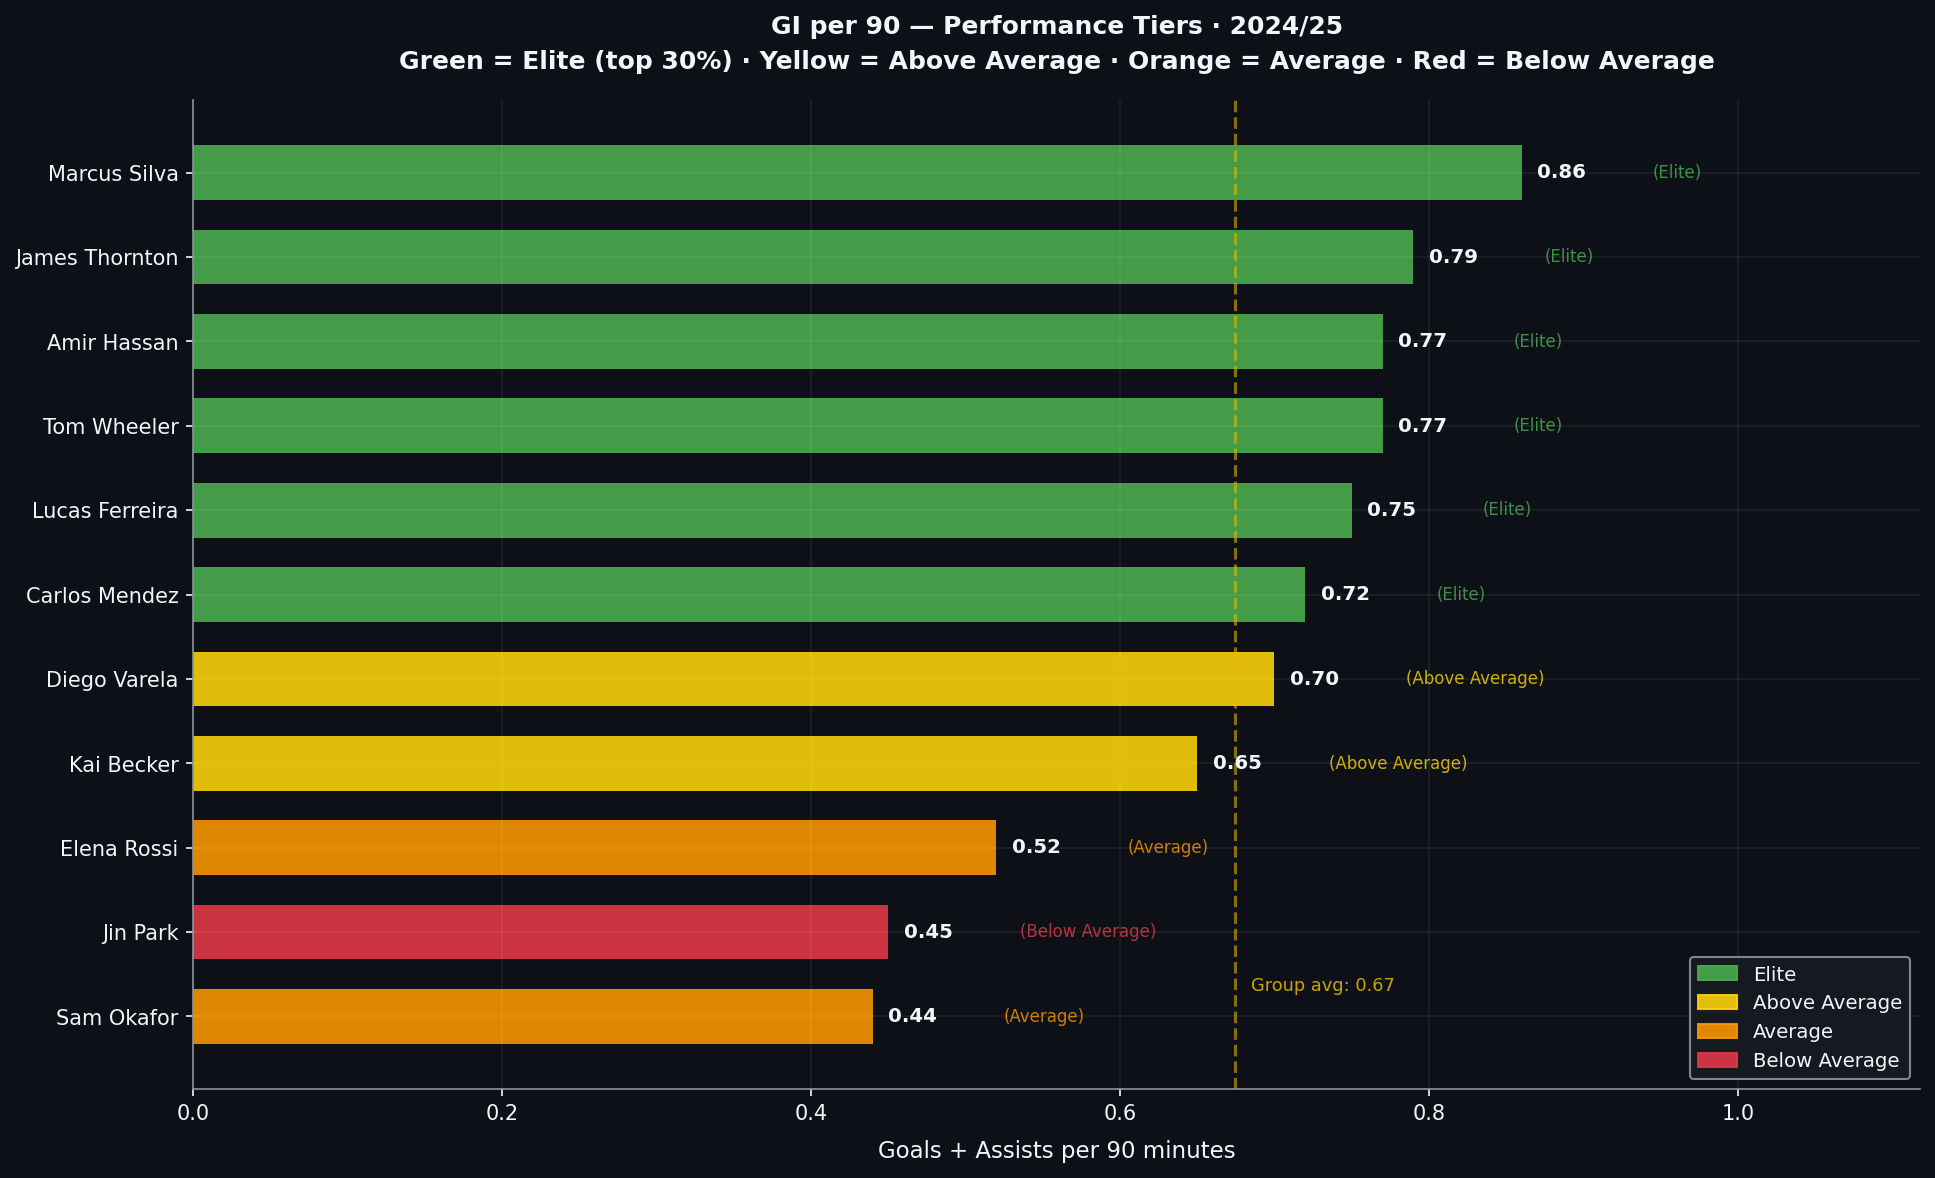

In [1]:
# CELL 8 — Tiered performance bar chart
# Each bar is coloured by performance tier, not by player identity
# This answers a different question: how many players are elite vs below average?

df_sorted = df.sort_values('gi_per90', ascending=True)

# Get the colour for each player's tier
tier_bar_colors = [TIER_COLORS[tier] for tier in df_sorted['tier']]

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG)

bars = ax.barh(df_sorted['player'], df_sorted['gi_per90'],
               color=tier_bar_colors, alpha=0.88, height=0.65)

# Value labels + tier labels
for bar, val, tier in zip(bars, df_sorted['gi_per90'], df_sorted['tier']):
    # GI/90 value
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            color=WHITE, fontsize=9.5, fontweight='bold')
    # Tier label — coloured to match the bar
    ax.text(bar.get_width() + 0.085,
            bar.get_y() + bar.get_height() / 2,
            f'({tier})', va='center',
            color=TIER_COLORS[tier], fontsize=8, alpha=0.80)

# Gold average line
avg = df_sorted['gi_per90'].mean()
ax.axvline(x=avg, color=GOLD, linestyle='--', alpha=0.55, linewidth=1.5)
ax.text(avg + 0.01, 0.3, f'Group avg: {avg:.2f}',
        color=GOLD, fontsize=8.5, alpha=0.85)

# Tier legend
legend_patches = [
    mpatches.Patch(color=c, label=t, alpha=0.88)
    for t, c in TIER_COLORS.items()
]
ax.legend(handles=legend_patches, loc='lower right',
          facecolor=BG3, edgecolor=GRAY, labelcolor=WHITE,
          fontsize=9.5, framealpha=0.9)

# Apply design system
style_axis(ax, xlabel='Goals + Assists per 90 minutes')
ax.set_xlim(0, df_sorted['gi_per90'].max() * 1.30)

ax.set_title('GI per 90 — Performance Tiers · 2024/25\n'
             'Green = Elite (top 30%) · Yellow = Above Average · '
             'Orange = Average · Red = Below Average',
             color=WHITE, fontsize=12, fontweight='bold',
             pad=15, linespacing=1.6)

plt.tight_layout()
plt.show()

### What This Chart Answers That the Previous One Doesn't

The player-coloured chart answers: *"How does each individual perform?"*

The tier-coloured chart answers: *"What is the distribution of performance quality
across the whole group?"*

From the tiered chart you can immediately see:
- **6 Elite players** — more than half the group is performing at a top-30% level
- **2 Above Average players** — a solid second tier
- **2 Average players** — sitting near the group mean
- **1 Below Average player** — Jin Park, youngest in the group at 19

**When to use which:**
- Use **player colours** when you are profiling individuals — the reader needs to
  track specific players across multiple charts
- Use **tier colours** when you are characterising a group — the reader needs to
  understand the distribution of quality, not individual identities

---
## Part 7 — Light Mode: The Same Chart, Different Theme

Not every publication uses a dark background. Academic papers, some newsletters,
and print publications work better with light backgrounds. The `style_axis()`
function handles this with `theme='light'`.

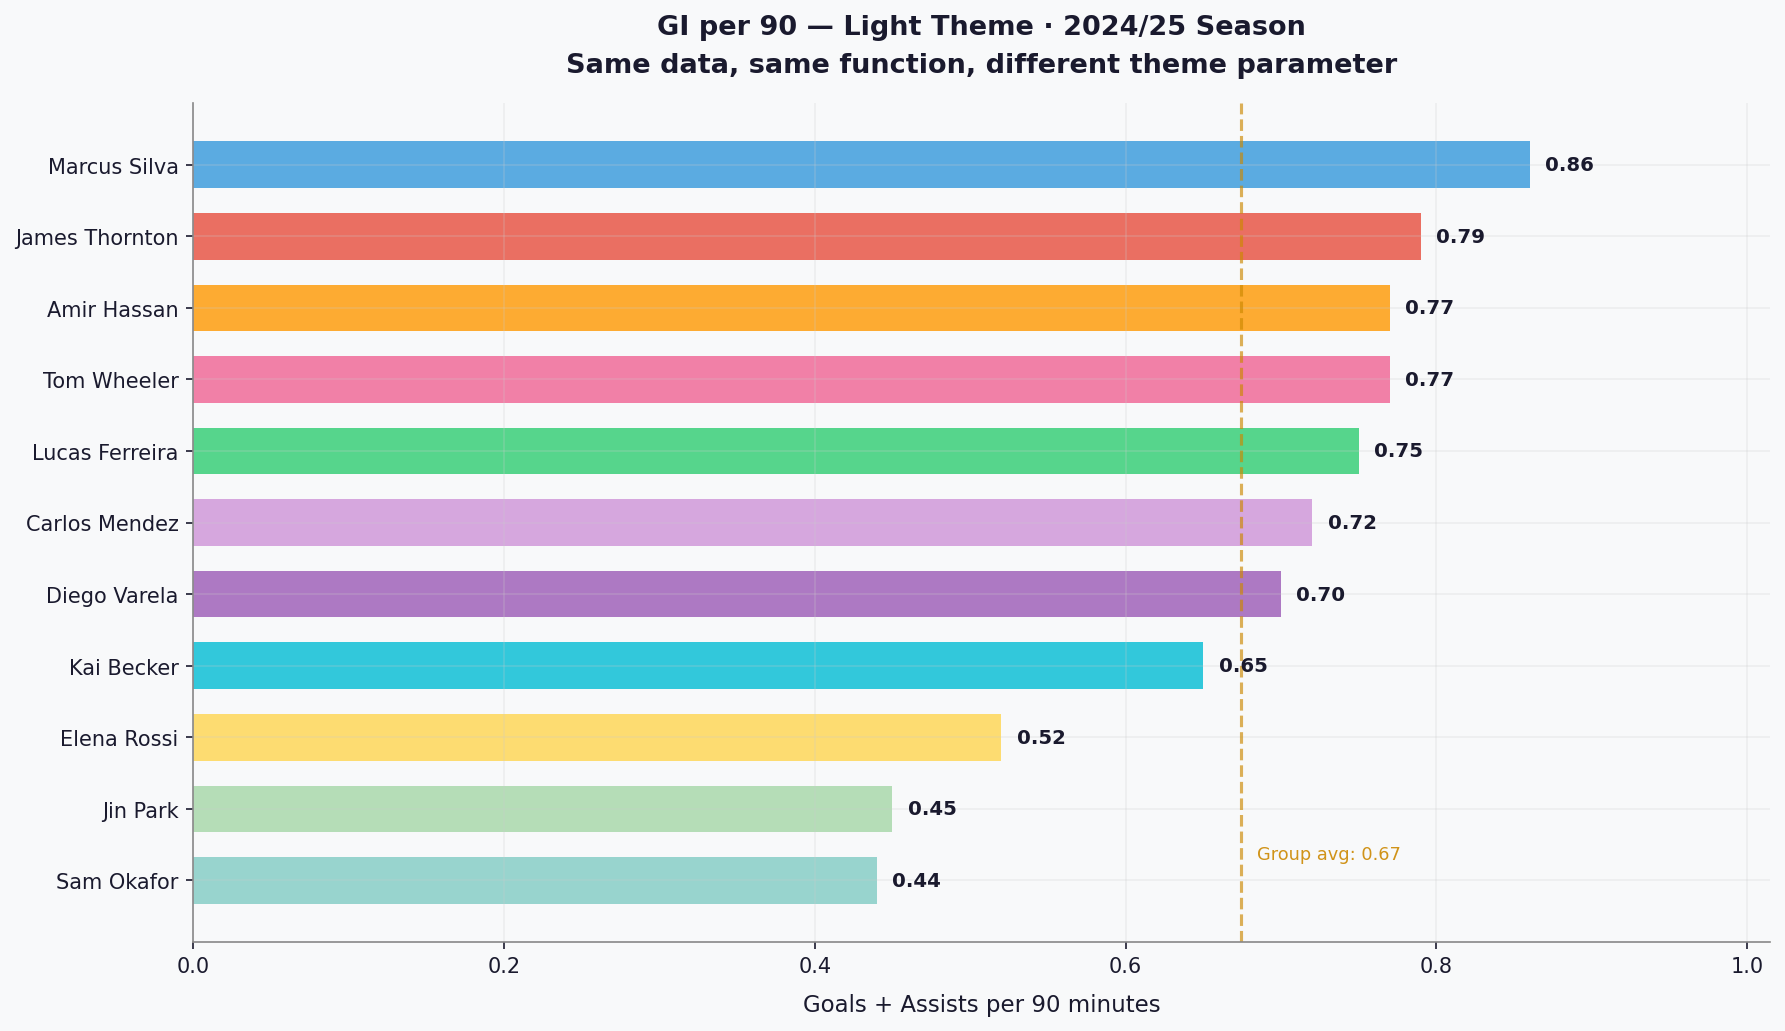

One parameter change. Completely different theme.
The style_axis() function handles all the text and grid colour switching.


In [1]:
# CELL 9 — Light theme chart
# Change theme='dark' to theme='light' in style_axis()
# Everything else stays identical

df_sorted = df.sort_values('gi_per90', ascending=True)
bar_colors = [PLAYER_COLORS.get(p, GRAY) for p in df_sorted['player']]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f8f9fa')     # Light figure background

bars = ax.barh(df_sorted['player'], df_sorted['gi_per90'],
               color=bar_colors, alpha=0.80, height=0.65)

for bar, val in zip(bars, df_sorted['gi_per90']):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            color='#1a1a2e', fontsize=9.5, fontweight='bold')

avg = df_sorted['gi_per90'].mean()
ax.axvline(x=avg, color='#cc8800', linestyle='--', alpha=0.65, linewidth=1.5)
ax.text(avg + 0.01, 0.3, f'Group avg: {avg:.2f}',
        color='#cc8800', fontsize=8.5, alpha=0.90)

# ← The only change: theme='light'
style_axis(ax, theme='light',
           xlabel='Goals + Assists per 90 minutes',
           title='GI per 90 — Light Theme · 2024/25 Season',
           subtitle='Same data, same function, different theme parameter')

ax.set_xlim(0, df_sorted['gi_per90'].max() * 1.18)
plt.tight_layout()
plt.show()

print("One parameter change. Completely different theme.")
print("The style_axis() function handles all the text and grid colour switching.")

---
## Part 8 — Your Turn

### Exercise 1 — Build a Custom Club Palette (Easy)

Create a new colour palette for a club of your choice.
For example, a Liverpool palette:

```python
LIVERPOOL_BG   = '#0d0d0d'    # near-black
LIVERPOOL_RED  = '#C8102E'    # official Liverpool red
LIVERPOOL_GOLD = '#F6EB61'    # official Liverpool gold
LIVERPOOL_TEXT = '#f0f6fc'    # white text
```

Then rebuild the "After" chart from Cell 7 using the Liverpool palette.
Change `BG` to `LIVERPOOL_BG` and replace the bar colour with `LIVERPOOL_RED`.

**Question:** Does the chart still work visually? What happens if you make
all the bars the same colour instead of unique per player?

---

### Exercise 2 — Add a World Class Tier (Medium)

The current tier system has 4 tiers: Elite, Above Average, Average, Below Average.
Add a fifth tier: **World Class** — for players above the 90th percentile.

Steps:
1. Add `'World Class': '#FFD700'` to the `TIER_COLORS` dictionary
2. Look at the `gi_percentile` column — which players are above 90?
3. Update their `tier` value in the DataFrame: `df.loc[df['gi_percentile'] > 90, 'tier'] = 'World Class'`
4. Rebuild the tiered bar chart from Cell 8

**Question:** How many players in this group qualify as World Class?
How does the chart look with 5 tiers instead of 4?

---

### Exercise 3 — The style_axis() Extension (Hard)

The current `style_axis()` function does not handle one thing:
**spine width**. Thicker axis spines look more professional in printed charts.

Add a `spine_width` parameter to the function:

```python
def style_axis(ax, theme='dark', xlabel=None, ylabel=None,
               title=None, subtitle=None, spine_width=1.0):
    # ... existing code ...
    ax.spines['bottom'].set_linewidth(spine_width)
    ax.spines['left'].set_linewidth(spine_width)
```

Then rebuild the "After" chart with `spine_width=2.0` and compare.
At what spine width does the chart start to look too heavy?

---

## Chapter Summary

| Concept | What You Learned |
|---------|-----------------|
| Why design matters | 8-second rule, pre-attentive attributes, perceptual psychology |
| The 5 design decisions | Background, grid, spines, typography, colour |
| Colour blindness | Design for everyone — pair colour with labels |
| `style_axis()` | One function that applies the full design system |
| Player colours vs tier colours | Two different questions, two different colour strategies |
| Light vs dark theme | Same `style_axis()` function, different `theme=` parameter |

### The Reusable Code This Chapter Gave You

From now on, every chapter imports two things from Chapter 3:
1. **The design system constants** (BG, WHITE, GOLD, GREEN, YELLOW, RED, TIER_COLORS, PLAYER_COLORS)
2. **The `style_axis()` function**

Copy both into any new notebook and your charts will be consistent, professional,
and publication-ready from the first cell.

---

## Up Next — Chapter 4: Tables That Tell Stories

Not everything is a chart. Sometimes a table communicates more clearly —
especially for direct numerical comparisons. Chapter 4 teaches pandas styling:
conditional formatting, colour-coded cells, ranked tables, and how to export
a professional-looking stats table for a newsletter or article.

---
*© 2026 HackrLife Media LLC · BarcaFutbol Analytics Course*
*[github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

**[Continue to Chapter 4 →](../Chapter-04-Tables-That-Tell-Stories/)**